In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


## Set some Defaults for plotting

In [2]:
LINEWIDTH = 3
COLOR_PALETTE = 'colorblind'

## Set some defaults for calculations

In [3]:
ORIGINAL_CONTROL_FREQ = 20

## Load pickle files for commanded vs reached over kp

In [4]:
from robomimic.dev.plotting.plot_utils import get_success_over_200_trials

can_commanded_20_hz = "/media/nadun/Data/phd_project/experiment_logs/sim/replay_demos/can/replay_over_kp_commanded/replay_20_hz.pkl"
can_commanded_40_hz = "/media/nadun/Data/phd_project/experiment_logs/sim/replay_demos/can/replay_over_kp_commanded/replay_40_hz.pkl"
can_reached_20_hz = "/media/nadun/Data/phd_project/experiment_logs/sim/replay_demos/can/replay_over_kp_reached/replay_fast_20_hz.pkl"
can_reached_40_hz = "/media/nadun/Data/phd_project/experiment_logs/sim/replay_demos/can/replay_over_kp_reached/replay_fast_40_hz.pkl"

# Get the success per value of the data, these dicts are of format {kwarg_val: success_rate}
can_commanded_20_hz_data = get_success_over_200_trials(log_fn=can_commanded_20_hz)
can_reached_20_hz_data = get_success_over_200_trials(log_fn=can_reached_20_hz)
can_commanded_40_hz_data = get_success_over_200_trials(log_fn=can_commanded_40_hz)
can_reached_40_hz_data = get_success_over_200_trials(log_fn=can_reached_40_hz)






## Plot Success vs Kp

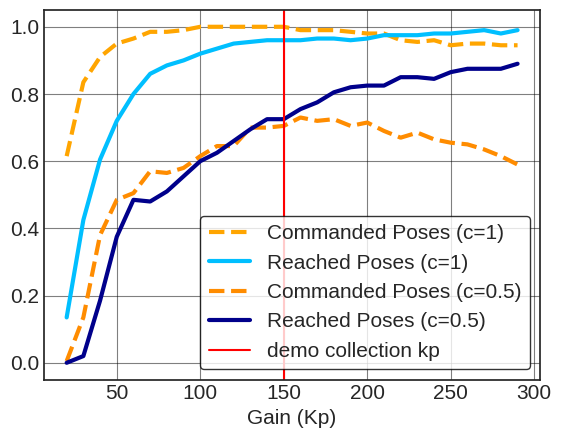

In [21]:
# Set plotting params
sns.set_palette(COLOR_PALETTE)
with plt.style.context("seaborn-v0_8-whitegrid"):
    plt.rcParams["axes.edgecolor"] = "0.15"
    plt.rcParams["axes.linewidth"]  = 1.25
    plt.rcParams["font.size"] = 15
    plt.rcParams['grid.color'] = 'black'
    plt.rcParams['grid.alpha'] = 0.5

    fig, ax = plt.subplots()


    sns.lineplot(can_commanded_20_hz_data, ax=ax, color="orange", label='Commanded Poses (c=1)', linestyle='--', linewidth=LINEWIDTH)
    sns.lineplot(can_reached_20_hz_data, ax=ax, color="deepskyblue", label='Reached Poses (c=1)', linewidth=LINEWIDTH)
    sns.lineplot(can_commanded_40_hz_data, ax=ax, color="darkorange", label='Commanded Poses (c=0.5)', linestyle='--', linewidth=LINEWIDTH)
    sns.lineplot(can_reached_40_hz_data, ax=ax, color="darkblue", label='Reached Poses (c=0.5)', linewidth=LINEWIDTH)
    plt.axvline(150, color="red", label="demo collection kp")


    ax.set_xlabel("Gain (Kp)")
    ax.legend(frameon=True, edgecolor='black', facecolor='white',)
    plt.show()

## Data for replay over speed and kp

In [22]:
from robomimic.dev.plotting.plot_utils import get_success_over_speed_and_kp
from collections import OrderedDict

can_replay_speed_kp_commanded_data = {20: {50: 190.0, 100: 200.0, 150: 200.0, 200: 196.0, 250: 189.0, 300: 189.0},
                            30: {50: 146.0, 100: 180.0, 150: 185.0, 200: 179.0, 250: 174.0, 300: 165.0},
                            40: {50: 97.0, 100: 123.0, 150: 141.0, 200: 143.0, 250: 131.0, 300: 114.0},
                            50: {50: 47.0, 100: 78.0, 150: 86.0, 200: 83.0, 250: 67.0, 300: 55.0},
                            60: {50: 4.0, 100: 25.0, 150: 24.0, 200: 21.0, 250: 15.0, 300: 15.0}}


can_replay_speed_kp_reached_data = {20: {50: 144.0, 100: 184.0, 150: 192.0, 200: 193.0, 250: 196.0, 300: 197.0},
                                    30: {50: 98.0, 100: 161.0, 150: 179.0, 200: 188.0, 250: 191.0, 300: 191.0},
                                    40: {50: 75.0, 100: 120.0, 150: 145.0, 200: 165.0, 250: 173.0, 300: 176.0},
                                    50: {50: 38.0, 100: 94.0, 150: 118.0, 200: 132.0, 250: 146.0, 300: 153.0},
                                    60: {50: 4.0, 100: 57.0, 150: 68.0, 200: 74.0, 250: 81.0, 300: 88.0}}


can_replay_speed_kp_commanded_success = get_success_over_speed_and_kp(can_replay_speed_kp_commanded_data)
can_replay_speed_kp_reached_success = get_success_over_speed_and_kp(can_replay_speed_kp_reached_data)

# Iterate over speeds, pick succes for low and high gain
can_commanded_low_gain_success = OrderedDict()
can_commanded_high_gain_success = OrderedDict()

can_reached_low_gain_success = OrderedDict()
can_reached_high_gain_success = OrderedDict()

for speed in can_replay_speed_kp_commanded_success:
    c = ORIGINAL_CONTROL_FREQ/speed
    s_low = can_replay_speed_kp_commanded_success[speed][100]
    s_high = can_replay_speed_kp_commanded_success[speed][300]
    can_commanded_low_gain_success[c] = s_low
    can_commanded_high_gain_success[c] = s_high

    s2_low = can_replay_speed_kp_reached_success[speed][100]
    s2_high = can_replay_speed_kp_reached_success[speed][300]
    can_reached_low_gain_success[c] = s2_low
    can_reached_high_gain_success[c] = s2_high





## Plot success over speed for high gain and low gain with reached and commanded poses

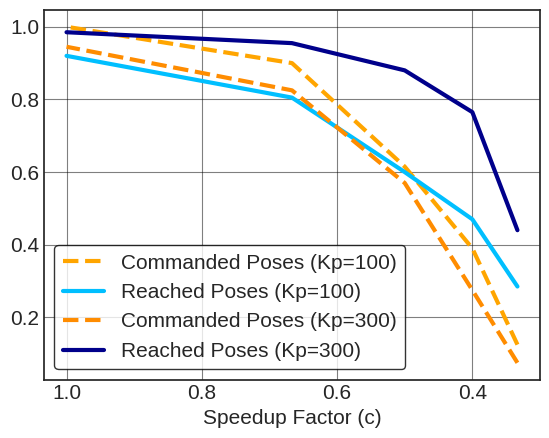

In [23]:
# Set plotting params
sns.set_palette(COLOR_PALETTE)
with plt.style.context("seaborn-v0_8-whitegrid"):
    plt.rcParams["axes.edgecolor"] = "0.15"
    plt.rcParams["axes.linewidth"]  = 1.25
    plt.rcParams["font.size"] = 15
    plt.rcParams['grid.color'] = 'black'
    plt.rcParams['grid.alpha'] = 0.5

    fig, ax = plt.subplots()




    sns.lineplot(can_commanded_low_gain_success, ax=ax, color="orange", label='Commanded Poses (Kp=100)', linestyle='--', linewidth=LINEWIDTH)
    sns.lineplot(can_reached_low_gain_success, ax=ax, color="deepskyblue", label='Reached Poses (Kp=100)', linewidth=LINEWIDTH)
    sns.lineplot(can_commanded_high_gain_success, ax=ax, color="darkorange", label='Commanded Poses (Kp=300)', linestyle='--', linewidth=LINEWIDTH)
    sns.lineplot(can_reached_high_gain_success, ax=ax, color="darkblue", label='Reached Poses (Kp=300)', linewidth=LINEWIDTH)


    
    ax.set_xlabel("Speedup Factor (c)")
    ax.legend(frameon=True, edgecolor='black', facecolor='white',)
    ax.invert_xaxis()
    plt.show()

## Plot success over gain two columns

/tmp/ipykernel_44136/3327607314.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust the layout for space for labels


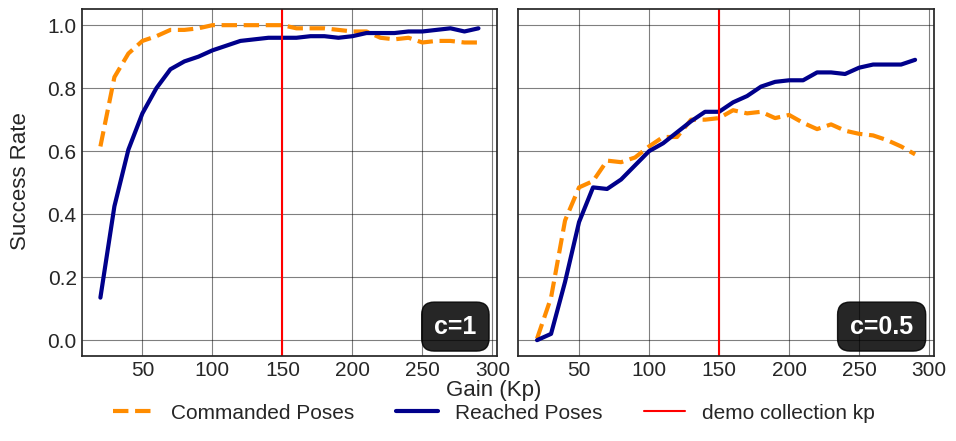

In [27]:
# Set plotting params
sns.set_palette(COLOR_PALETTE)
with plt.style.context("seaborn-v0_8-whitegrid"):
    plt.rcParams["axes.edgecolor"] = "0.15"
    plt.rcParams["axes.linewidth"]  = 1.25
    plt.rcParams["font.size"] = 15
    plt.rcParams['grid.color'] = 'black'
    plt.rcParams['grid.alpha'] = 0.5

    fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(11, 4.5), gridspec_kw={'wspace': 0.05})


    sns.lineplot(can_commanded_20_hz_data, ax=ax[0], color="darkorange", label='Commanded Poses', linestyle='--', linewidth=LINEWIDTH, legend=False)
    sns.lineplot(can_reached_20_hz_data, ax=ax[0], color="darkblue", label='Reached Poses', linewidth=LINEWIDTH, legend=False)
    sns.lineplot(can_commanded_40_hz_data, ax=ax[1], color="darkorange", label='Commanded Poses', linestyle='--', linewidth=LINEWIDTH, legend=False)
    sns.lineplot(can_reached_40_hz_data, ax=ax[1], color="darkblue", label='Reached Poses', linewidth=LINEWIDTH, legend=False)
    ax[0].axvline(150, color="red", label="demo collection kp")
    ax[1].axvline(150, color="red", label="demo collection kp")

    # Add speed label
    ax[0].text(0.95, 0.05, "c=1", transform=ax[0].transAxes,
                   fontsize=18, fontweight="bold", color="white",
                   ha="right", va="bottom",
                   bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="black", alpha=0.85))

    ax[1].text(0.95, 0.05, "c=0.5", transform=ax[1].transAxes,
                   fontsize=18, fontweight="bold", color="white",
                   ha="right", va="bottom",
                   bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="black", alpha=0.85))


    # Add shared x-axis and y-axis labels
    fig.supxlabel("Gain (Kp)", fontsize=16, y=0.01)
    fig.supylabel("Replay Success Rate", fontsize=16, x=0.06)

     # Collect handles and labels for the shared legend
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))

    # Adjust layout
    fig.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust the layout for space for labels

    # Show plot
    plt.show()



# Exp2: Noise vs High Gain and Low Gain

In [ ]:
from robomimic.dev.plotting.plot_utils import get_success_rate_over_kwargs

log_fn_high_kp = "/media/nadun/Data/phd_project/robomimic/bc_trained_models/rss/sim/speed_adaptive_models/can_image_action_horizon_16_speed_adaptive/20250114173246/logs/time_capped/noisy_eval_kp_250/noisy_eval_2025-01-16 18:54:39.610914.pkl"
log_fn_low_kp = "/media/nadun/Data/phd_project/robomimic/bc_trained_models/rss/sim/speed_adaptive_models/can_image_action_horizon_16_speed_adaptive/20250114173246/logs/time_capped/noisy_eval_kp_100/noisy_eval_2025-01-16 18:54:19.591218.pkl"

high_kp_success =  get_success_rate_over_kwargs(log_fn=log_fn_high_kp, return_array=True)
low_kp_success = get_success_rate_over_kwargs(log_fn=log_fn_low_kp, return_array=True)

